In [59]:
import pandas as pd

from src.biotools.fasta_tools import ExtractSequence

df = pd.read_csv('../uvsx/data/curated_database/cleaned_metadata.csv')

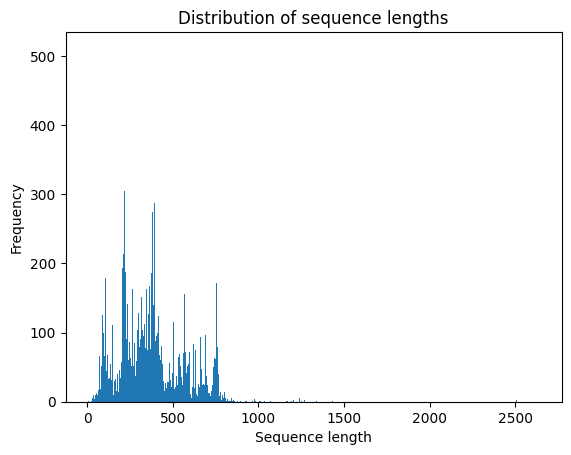

In [60]:

import matplotlib.pyplot as plt

def PlotSequenceLenths(fasta_file):

    seq_lengths = []

    with open(fasta_file) as f:
        seq = ''
        header = None

        for line in f:
            line = line.strip()

            if line.startswith('>'):
                # process previous sequence
                if seq:
                    seq_lengths.append(len(seq))


                header = line
                seq = ''
            else:
                seq += line

        # handle last sequence
        if seq:
            seq_lengths.append(len(seq))


    plt.hist(seq_lengths, bins=1000)
    plt.xlabel("Sequence length")
    plt.ylabel("Frequency")
    plt.title("Distribution of sequence lengths")
    plt.show()


In [61]:
import pandas as pd
import json

# Load NCBI CSV
ncbi_df = pd.read_csv('../uvsx/data/curated_database/ncbi_query_search_metadata.csv', low_memory=False)
ncbi_lookup = {
    str(row['accession']): row['taxonId']
    for _, row in ncbi_df.iterrows()
}

# Load UniProt JSON
with open('../uvsx/data/curated_database/uniprot_query_search_metadata.json') as f:
    uniprot_data = json.load(f)

uniprot_lookup = {
    entry.get('primaryAccession'): entry.get('organism', {}).get('taxonId')
    for entry in uniprot_data
}

taxonids = []

for acc in df['accession']:
    acc = str(acc)

    if acc in ncbi_lookup:
        taxonids.append(ncbi_lookup[acc])
        continue

    if acc in uniprot_lookup:
        taxonids.append(uniprot_lookup[acc])
        continue

    taxonids.append(None)

print(f"Taxon ids: {len(taxonids)}\nNumber of accessions: {len(df['accession'])}")

Taxon ids: 20549
Number of accessions: 20549


In [62]:
import requests
from time import sleep
import xml.etree.ElementTree as ET

API_KEY = "eb2c0b97f55a588259931f07f1099b896207"


def fetch_taxonomy_ranked_lineage_list(taxids, batch_size=200):

    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    input_taxids = [str(t) for t in taxids if t is not None]

    results = []

    for i in range(0, len(input_taxids), batch_size):
        batch = input_taxids[i:i + batch_size]

        params = {
            "db": "taxonomy",
            "id": ",".join(batch),
            "retmode": "xml",
            "api_key": API_KEY
        }

        res = requests.get(url, params=params)
        root = ET.fromstring(res.text)

        # Build temporary lookup for this batch
        batch_lookup = {}

        for taxon in root.findall(".//Taxon"):
            taxid_node = taxon.find("TaxId")
            if taxid_node is None:
                continue

            taxid = taxid_node.text
            lineage_dict = {}

            lineage_ex = taxon.find("LineageEx")

            if lineage_ex is not None:
                for node in lineage_ex.findall("Taxon"):
                    rank_node = node.find("Rank")
                    name_node = node.find("ScientificName")

                    if rank_node is not None and name_node is not None:
                        rank = rank_node.text.lower()
                        name = name_node.text

                        if rank != "no rank":
                            lineage_dict[rank] = name

            current_rank = taxon.find("Rank")
            current_name = taxon.find("ScientificName")

            if current_rank is not None and current_name is not None:
                rank = current_rank.text.lower()
                name = current_name.text

                if rank != "no rank":
                    lineage_dict[rank] = name

            batch_lookup[taxid] = lineage_dict

        # ✅ Preserve original order + duplicates
        for t in batch:
            results.append({
                "taxid": t,
                "lineage": batch_lookup.get(t)
            })

        sleep(0.3)

    return results

In [63]:
lineages=fetch_taxonomy_ranked_lineage_list(taxonids)

In [64]:
len(lineages)
ids=[]
for i in lineages:
    ids.append(i['taxid'])

In [80]:
genera = []

for i in range(len(lineages)):
    if lineages[i] is not None:
        lineage = lineages[i].get('lineage')
        if lineage is not None:
            genus = lineage.get('order')
        else:
            genus = None
    else:
        genus = None

    genera.append(genus)



In [81]:
counts={}
for g in genera:
    if g not in counts.keys():
        counts[g]=0
    if g in counts.keys():
        counts[g]+=1


In [82]:
counter=0
for c in counts.items():
    if c[1]>1:
        print(c)

('Pantevenvirales', 899)
('Autographivirales', 931)
(None, 17880)
('Lefavirales', 315)
('Imitervirales', 185)
('Geplafuvirales', 3)
('Picornavirales', 3)
('Pimascovirales', 26)
('Crassvirales', 91)
('Amphintovirales', 4)
('Grandevirales', 2)
('Kalamavirales', 11)
('Mindivirales', 4)
('Algavirales', 45)
('Petitvirales', 6)
('Tubulavirales', 29)
('Ortervirales', 10)
('Herpesvirales', 29)
('Chitovirales', 4)
('Asfuvirales', 19)
('Kirjokansivirales', 2)
('Methanobavirales', 2)
('Mononegavirales', 6)
('Haloruvirales', 4)
('Juravirales', 2)
('Thumleimavirales', 19)
('Tymovirales', 9)
('Martellivirales', 5)


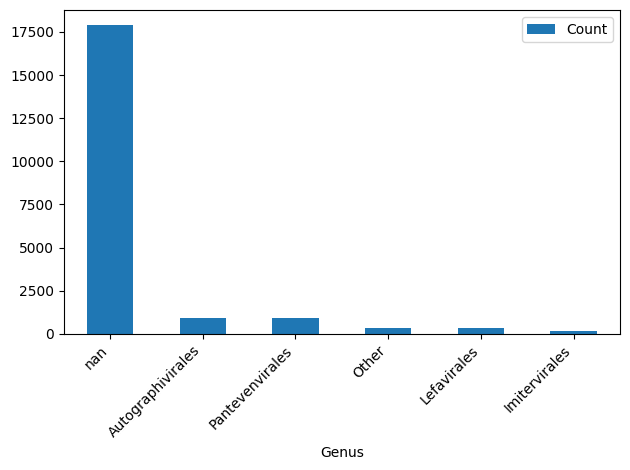

In [83]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(list(counts.items()), columns=['Virus', 'Count'])

# Define threshold (e.g. <=1 gets grouped)
threshold = 100

# Split into major + minor
major = df[df['Count'] > threshold]
minor = df[df['Count'] <= threshold]

# Sum minor counts into "Other"
other_count = minor['Count'].sum()

# Add "Other" row if needed
if other_count > 0:
    major = pd.concat([major, pd.DataFrame([['Other', other_count]], columns=['Virus', 'Count'])])

# Sort again
major = major.sort_values(by='Count', ascending=False)

# Plot
major.plot(kind='bar', x='Virus', y='Count')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Genus')
plt.tight_layout()
plt.show()

In [56]:
from collections import defaultdict

collapse_map = {
    'subphylum': 'phylum',
    'suborder': 'order',
    'subfamily': 'family',
    'subgenus': 'genus'
}

rank_values = defaultdict(set)

for entry in lineages:
    lineage = entry.get("lineage")

    if not lineage:
        continue

    for rank, value in lineage.items():
        # collapse rank first
        new_rank = collapse_map.get(rank, rank)
        rank_values[new_rank].add(value)

# Now count unique values per collapsed rank
collapsed_counts = {rank: len(values) for rank, values in rank_values.items()}

/var/folders/7y/g8zz31hx47955l5hvty2hyzh0000gn/T/ipykernel_3220/2204193484.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['Rank'] = pd.Categorical(df['Rank'], categories=rank_order, ordered=True)


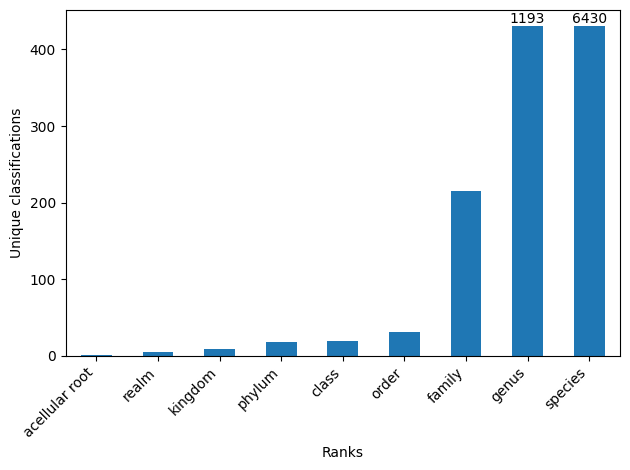

In [58]:
# ---- Plot ----
df = pd.DataFrame(list(collapsed_counts.items()), columns=['Rank', 'Count'])

rank_order = [
    'acellular root','realm','kingdom','phylum','class','order',
    'family','genus','species'
]

df['Rank'] = pd.Categorical(df['Rank'], categories=rank_order, ordered=True)
df = df.sort_values('Rank')
df = df[df['Rank'].notna()]

sorted_counts = df['Count'].sort_values(ascending=False).values
scale_value = sorted_counts[2] if len(sorted_counts) >= 3 else sorted_counts[-1]
cap_value = scale_value * 2

df_plot = df.copy()
real_values = {}

for i, row in df.iterrows():
    if row['Count'] > cap_value:
        real_values[row['Rank']] = row['Count']
        df_plot.loc[i, 'Count'] = cap_value

ax = df_plot.plot(kind='bar', x='Rank', y='Count', legend=False)

for i, row in df_plot.iterrows():
    rank = row['Rank']
    if rank in real_values:
        ax.text(i, cap_value, f"{real_values[rank]}",
                ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Unique classifications")
plt.xlabel('Ranks')
plt.tight_layout()
plt.show()

In [ ]:
print('done')